In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

In [2]:
def get_ciss_raw(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path, skiprows=8, encoding='Windows-1252')
            df = df.iloc[:-1]  # Remove the last row
            df.rename(columns={"Unix TimeStamp (ms)": "TimeStamp", "Data / x_axis": "x_axis"}, inplace=True)
            df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
            df.drop(columns=["Measurement Type"], inplace=True)
            if directory.__contains__("Worn"):
                df["Label"] = 1
            if directory.__contains__("Good"):
                df["Label"] = 0
            dataframes.append(df)
    df = pd.concat(dataframes)
    return df

In [3]:
def get_registry_record(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            df.rename(columns={"Unnamed: 0": "TimeStamp"}, inplace=True)
            df["TimeStamp"] = df["TimeStamp"].astype(str).str.replace(".", "", regex=False).str[:13]
            df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
            df.drop(columns=["WinPCNCRunning", "CurrentJobProgress", "CurrentJobTimeMin", "CurrentJobTimeSec", "CurrentJobCommandNo", "CurrentSpdOvr", "State"], inplace=True)
            dataframes.append(df)
    df = pd.concat(dataframes)
    return df


In [4]:
def make_windows(dataframe, num_windows):
    window_size = len(dataframe) // num_windows
    step_size = window_size
    windows = []

    for i in range(0, len(dataframe), step_size):
        if i + window_size > len(dataframe):
            break

        window_data = dataframe.iloc[i:i+window_size]

        # Feature extraction
        features = {
            'x_mean': window_data['x_axis'].mean(),
            'x_std': window_data['x_axis'].std(),
            'x_sum': window_data['x_axis'].sum(),
            'x_median': window_data['x_axis'].median(),
            'y_mean': window_data['y_axis'].mean(),
            'y_std': window_data['y_axis'].std(),
            'y_sum': window_data['y_axis'].sum(),
            'y_median': window_data['y_axis'].median(),
            'z_mean': window_data['z_axis'].mean(),
            'z_std': window_data['z_axis'].std(),
            'z_sum': window_data['z_axis'].sum(),
            'z_median': window_data['z_axis'].median(),
        }

        label = window_data["Label"].mode()[0]
        features["Label"] = label

        windows.append(features)
    
    windowed_data = pd.DataFrame(windows)

    return windowed_data

In [5]:
# Define the directories of the .csv files
current_dir = Path().resolve().parents[2]
directories_train = ["Worn_tool_no1_pattern1", "Worn_tool_no2_pattern2", "Worn_tool_no3_pattern3",
                        "Good_tool_no1_pattern4", "Good_tool_no2_pattern5"]
#directories_val = ["Worn_tool_no3_pattern3", "Good_tool_no2_pattern5"]

In [6]:
# Read out all the csv files for CISS and registry for train/test
dataframes_ciss = []
for directory in directories_train:
    connected_path = os.path.join(current_dir, "mlproject", "data", "raw", directory, "CISSRawData_LogFiles")
    dataframes_ciss.append(get_ciss_raw(connected_path))

dataframes_registry = []
for directory in directories_train:
    connected_path = os.path.join(current_dir, "mlproject", "data", "raw", directory)
    dataframes_registry.append(get_registry_record(connected_path))

In [7]:
dataframe_ciss = pd.concat(dataframes_ciss)
dataframe_ciss = dataframe_ciss.sort_values("TimeStamp", ascending=True)
dataframe_registry = pd.concat(dataframes_registry)
dataframe_registry = dataframe_registry.sort_values("TimeStamp", ascending=True)

In [8]:
dataframe_all = pd.merge_asof(dataframe_ciss, dataframe_registry, on="TimeStamp", direction="nearest")

In [9]:
peak_threshold = dataframe_all["Pos_Z"].max()
dataframe_all = dataframe_all[dataframe_all["Pos_Z"] >= peak_threshold]

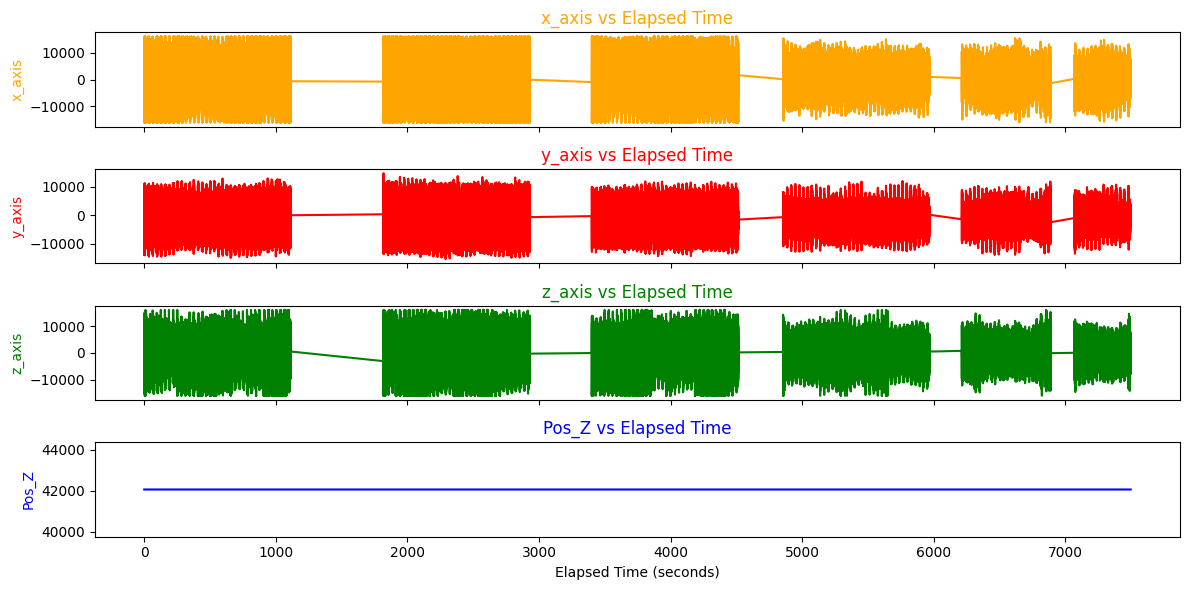

In [10]:
# Convert TimeStamp from numeric to datetime
dataframe_all['TimeStamp'] = pd.to_datetime(dataframe_all['TimeStamp'], unit='ms')

# List of columns to plot
columns_to_plot = ['x_axis', 'y_axis', 'z_axis', 'Pos_Z']

# Calculate the elapsed time since the recording started
dataframe_all['Elapsed_Time'] = (dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]).dt.total_seconds()

# Plot the data with the elapsed time
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(12, 6), sharex=True)
colors = ['orange', 'red', 'green', 'blue']

# Plot each column
for ax, col, color in zip(axes, columns_to_plot, colors):
    ax.plot(dataframe_all['Elapsed_Time'], dataframe_all[col], label=col, color=color)
    ax.set_title(f'{col} vs Elapsed Time', color=color)  # Optional: Title color matches line
    ax.set_ylabel(col, color=color)  # Optional: Y-axis label matches color

# Set common x-axis label
plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()

In [11]:
dataframe_all.drop(columns={"Pos_X", "Pos_Y", "Pos_Z"}, inplace=True)

In [12]:
windowed_data = make_windows(dataframe_all, 9000)

In [13]:
windowed_data.to_csv("windowed.csv")

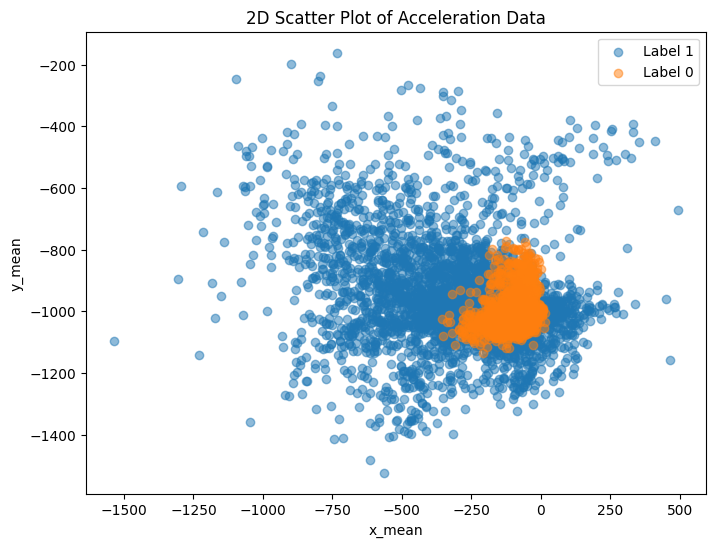

In [14]:
plt.figure(figsize=(8, 6))
for label in windowed_data["Label"].unique():
    subset = windowed_data[windowed_data["Label"] == label]
    plt.scatter(subset["x_mean"], subset["y_mean"], label=f"Label {label}", alpha=0.5)

plt.xlabel("x_mean")
plt.ylabel("y_mean")
plt.title("2D Scatter Plot of Acceleration Data")
plt.legend()
plt.show()

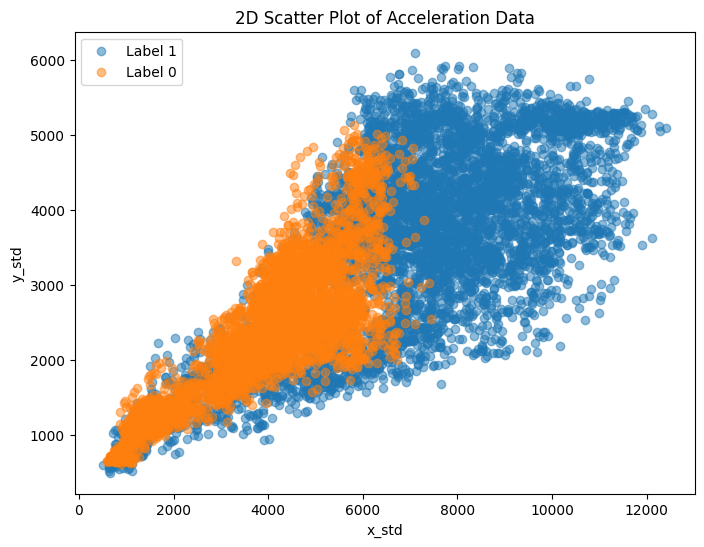

In [15]:
plt.figure(figsize=(8, 6))
for label in windowed_data["Label"].unique():
    subset = windowed_data[windowed_data["Label"] == label]
    plt.scatter(subset["x_std"], subset["y_std"], label=f"Label {label}", alpha=0.5)

plt.xlabel("x_std")
plt.ylabel("y_std")
plt.title("2D Scatter Plot of Acceleration Data")
plt.legend()
plt.show()

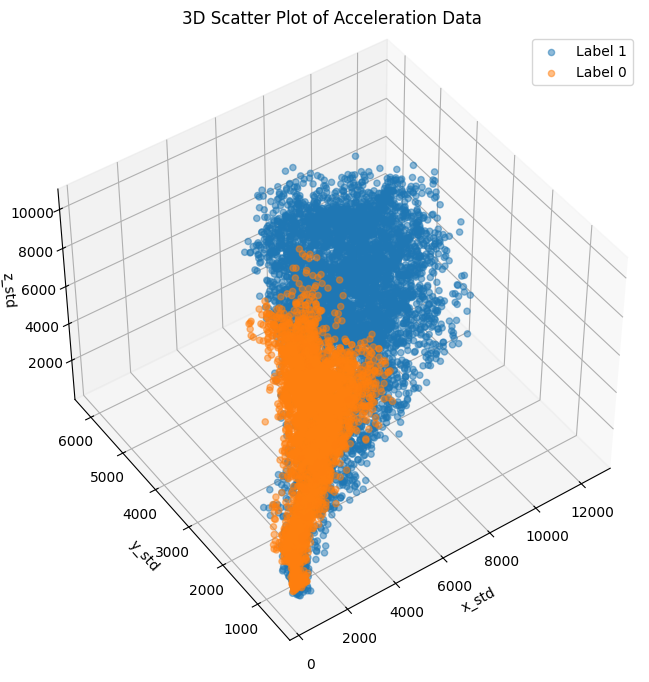

In [18]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for label in windowed_data['Label'].unique():
    subset = windowed_data[windowed_data['Label'] == label]
    ax.scatter(subset['x_std'], subset['y_std'], subset['z_std'], label=f"Label {label}", alpha=0.5)

ax.set_xlabel("x_std")
ax.set_ylabel("y_std")
ax.set_zlabel("z_std")
ax.set_title("3D Scatter Plot of Acceleration Data")
ax.legend()
ax.view_init(45, 235)
plt.show()